# Phase 7 -- Curvature-Conditioned Crossmodal Alignment: reading the frozen record

**Research question** (`07-CONTEXT.md` Sec 1, the developer's own framing): does the curvature
of the PU embedding manifold explain the weak crossmodal convergence reported by the Platonic
Universe paper ([arXiv:2509.19453](https://arxiv.org/abs/2509.19453))?

- If **NO** -- curvature does not account for the poor crossmodal MKNN, and that explanation is
  removed from the table.
- If **YES** -- there is a route to alignment measures that condition on curvature, which may
  recover convergence more in line with the Platonic Representation Hypothesis.

**Either answer is a result. A No is only publishable with the D7-02 power evidence** shown
further down (the positive control) -- without it, a null cannot be distinguished from an
underpowered test.

This notebook reads the frozen record produced by plan 07-04
(`notebooks/.cache/07_crossmodal_curvature.jsonl`, 8 rows) and the per-`d` field arrays
(`notebooks/.cache/07_crossmodal_curvature_fields.npz`). It recomputes no decoder fit, no
permutation test, and no headline statistic -- every number below is *read*, not *derived*. The
one exception -- explained and verified at the point it happens -- is the raw per-point MKNN
array needed for the scatter plot, which the frozen `.npz` does not persist (it is
`d`-independent and only its already-averaged diagnostics were written to the record).

In [1]:
%matplotlib inline
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import sys
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from pu_manifold import crossmodal_curvature as cc  # frozen module, imported unchanged

RECORD_PATH = Path(".cache/07_crossmodal_curvature.jsonl")
FIELDS_PATH = Path(".cache/07_crossmodal_curvature_fields.npz")

rows = [json.loads(line) for line in RECORD_PATH.open()]
sweep_rows = {r["d"]: r for r in rows if r["row_kind"] == "sweep"}
pc_rows = [r for r in rows if r["row_kind"] == "positive_control"]
verdict_row = next(r for r in rows if r["row_kind"] == "verdict")
fields = np.load(FIELDS_PATH)

assert set(sweep_rows) == set(cc.D_SWEEP), "sweep rows must cover exactly D_SWEEP"

freeze_commit = verdict_row["preregistration_commit"]
run_commit = verdict_row["run_commit"]
n = sweep_rows[cc.D_SWEEP[0]]["n"]
k = cc.HEADLINE_K

print(f"freeze commit (preregistration_commit): {freeze_commit}")
print(f"run commit:                              {run_commit}")
print(f"n = {n}, HEADLINE_K = {k}, D_SWEEP = {cc.D_SWEEP}")

n_distinct = sweep_rows[cc.D_SWEEP[0]]["mknn_n_distinct_by_k"][str(k)]
print(
    f"\nper-point MKNN_i is j/k for integer j in {{0, ..., k}}: at k={k} that is at most "
    f"{k + 1} distinct values across n={n} points (identical across d -- MKNN depends only on "
    f"the frozen embeddings and k, never on the curvature field). Measured distinct count: "
    f"{n_distinct}."
)

freeze commit (preregistration_commit): f032745f6450068c63763993d39fa112fd36bb8c
run commit:                              a4537369be204b784d026ac36c6bfc7b14ea483d
n = 10000, HEADLINE_K = 20, D_SWEEP = (20, 25, 32)

per-point MKNN_i is j/k for integer j in {0, ..., k}: at k=20 that is at most 21 distinct values across n=10000 points (identical across d -- MKNN depends only on the frozen embeddings and k, never on the curvature field). Measured distinct count: 15.


## Headline: the three-`d` sweep

One row per `d` in `D_SWEEP = (20, 25, 32)`, read directly off the record's `sweep` rows --
holdout variance explained, `cond(g)` median, `||H||` median, the observed Spearman rho, both
tails' permutation thresholds, `clears_either`, and `direction`.

In [2]:
table_rows = []
for d in cc.D_SWEEP:
    r = sweep_rows[d]
    table_rows.append({
        "d": d,
        "var_explained": round(r["var_explained"], 5),
        "cond_g_median": round(r["cond_g_median"], 2),
        "h_norm_median": round(r["h_norm_median"], 2),
        "observed_rho": round(r["observed_rho"], 5),
        "neg_tail_thresh": round(r["negative_tail_threshold"], 5),
        "pos_tail_thresh": round(r["positive_tail_threshold"], 5),
        "clears_either": r["clears_either"],
        "direction": r["direction"],
    })
df = pd.DataFrame(table_rows).set_index("d")
df

,var_explained,cond_g_median,h_norm_median,observed_rho,neg_tail_thresh,pos_tail_thresh,clears_either,direction
d,,,,,,,,
20,0.98194,15.73,37.19,-0.11218,0.02062,0.02098,True,negative
25,0.98432,17.98,41.41,-0.12789,0.01968,0.01890,True,negative
32,0.98647,15.54,47.03,-0.02373,0.01873,0.01861,True,negative


## `||H||` vs per-point MKNN -- the banding shown, not hidden

The per-point MKNN statistic is `j/k` for integer `j`, so at `k=HEADLINE_K=20` there are at most
21 distinct horizontal bands across the whole `n=10,000` cloud (measured: 15 above). That
banding is real tie structure, not a plotting artifact -- it is shown below rather than smoothed
away.

**A note on this one recomputation.** The frozen fields `.npz` stores `||H||` and `cond(g)` per
`d` but not the raw per-point MKNN array, because MKNN is `d`-independent and only its
already-averaged diagnostics (`spearman_density_vs_mknn`, `mknn_n_distinct_by_k`) were written
to the record. The scatter this cell draws needs the raw array, so this cell recomputes it once,
via the exact frozen `crossmodal_curvature.per_point_mknn` function on the same cached PU
embeddings 07-04 read (`notebooks/.cache/subsample_*.npz`) -- not a second implementation with
its own conventions. Immediately below, the recomputed array is checked against the frozen
record's own `d=20` `observed_rho`: **exact agreement is the proof**, not an assumption, that
this is a read of the frozen pipeline's own array rather than a drifted second computation.

recomputed spearman(||H||_20, MKNN) = -0.1121807159
frozen record observed_rho (d=20)   = -0.1121807159
Exact reproduction confirmed: this is a read of the frozen pipeline's own array, not a drifted second computation.



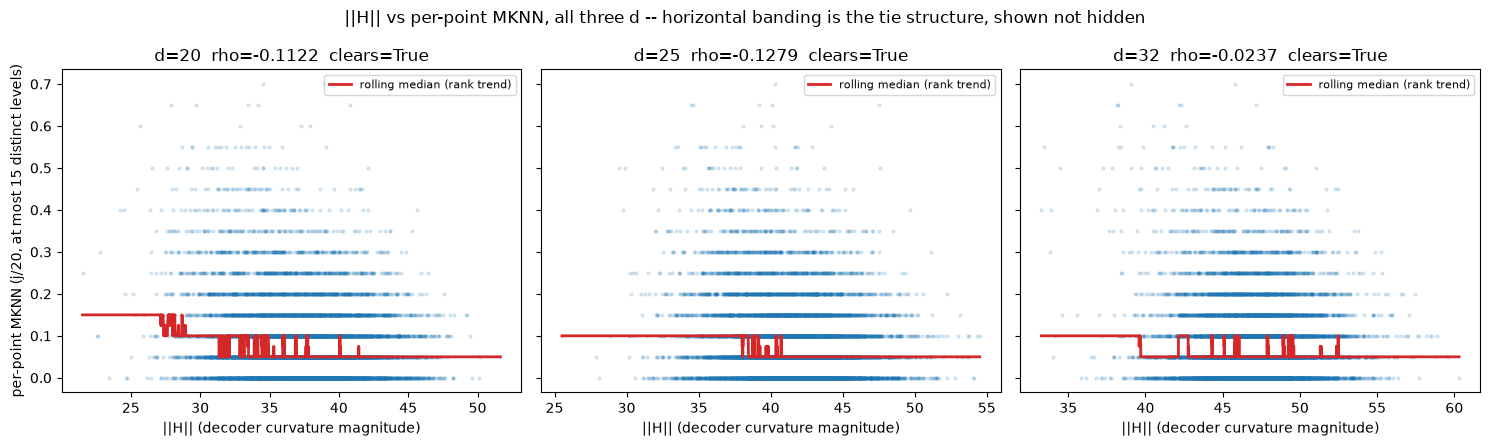

In [3]:
cands = sorted(glob.glob(".cache/subsample_*.npz"))
best, best_n = None, -1
for c in cands:
    with np.load(c) as z:
        if "hsc" in z.files and "legacysurvey" in z.files and z["hsc"].shape[0] > best_n:
            best, best_n = c, z["hsc"].shape[0]
with np.load(best) as z:
    X_hsc = np.asarray(z["hsc"], dtype=np.float64)
    X_ls = np.asarray(z["legacysurvey"], dtype=np.float64)

m_headline = cc.per_point_mknn(X_hsc, X_ls, cc.HEADLINE_K)

check_rho = spearmanr(fields["h_norm_20"], m_headline).statistic
recorded_rho = sweep_rows[20]["observed_rho"]
print(f"recomputed spearman(||H||_20, MKNN) = {check_rho:.10f}")
print(f"frozen record observed_rho (d=20)   = {recorded_rho:.10f}")
assert abs(check_rho - recorded_rho) < 1e-9, "recomputed MKNN array does NOT reproduce the frozen record -- STOP"
print("Exact reproduction confirmed: this is a read of the frozen pipeline's own array, not a drifted second computation.\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, d in zip(axes, cc.D_SWEEP):
    h = fields[f"h_norm_{d}"]
    order = np.argsort(h)
    h_sorted = h[order]
    m_sorted = m_headline[order]
    trend = pd.Series(m_sorted).rolling(200, center=True, min_periods=50).median()
    ax.scatter(h, m_headline, s=4, alpha=0.15, color="tab:blue", rasterized=True)
    ax.plot(h_sorted, trend, color="tab:red", lw=2, label="rolling median (rank trend)")
    r = sweep_rows[d]
    ax.set_title(f"d={d}  rho={r['observed_rho']:.4f}  clears={r['clears_either']}")
    ax.set_xlabel("||H|| (decoder curvature magnitude)")
    if ax is axes[0]:
        ax.set_ylabel("per-point MKNN (j/20, at most 15 distinct levels)")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("||H|| vs per-point MKNN, all three d -- horizontal banding is the tie structure, shown not hidden")
plt.tight_layout()
plt.show()

## `||H||` distributions -- order of magnitude only

**Spread is reported only as an order of magnitude, never as a precise quantity.** The
instrument's own est/true `||H||` ratio was measured swinging 0.665 to 1.626 non-monotonically
across a 17-fold range of true spread (`07-CONTEXT.md` Sec 4) -- estimated spread is a noisy
readout, and that includes PU's own numbers below.

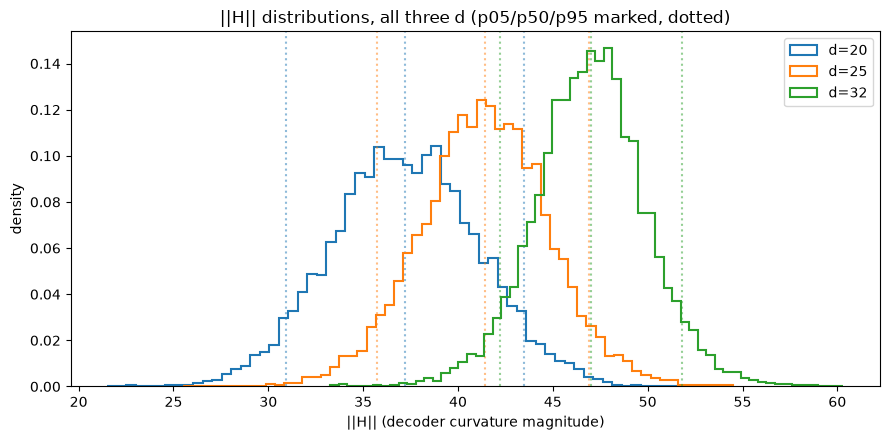

Spread, order of magnitude only:
  d=20: p05=30.9  p50=37.2  p95=43.5  (p95/p05 ratio order 1.41, i.e. 'low, order 2')
  d=25: p05=35.8  p50=41.4  p95=46.9  (p95/p05 ratio order 1.31, i.e. 'low, order 2')
  d=32: p05=42.2  p50=47.0  p95=51.8  (p95/p05 ratio order 1.23, i.e. 'low, order 2')

Estimated spread is a noisy readout because the instrument's est/true ||H|| ratio was measured swinging 0.665 to 1.626 non-monotonically across a 17-fold range of true spread (07-CONTEXT.md Sec 4). None of the numbers above should be read as a precise quantity.


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {20: "tab:blue", 25: "tab:orange", 32: "tab:green"}
for d in cc.D_SWEEP:
    h = fields[f"h_norm_{d}"]
    ax.hist(h, bins=60, histtype="step", density=True, color=colors[d], label=f"d={d}", lw=1.5)
    r = sweep_rows[d]
    for val in (r["h_norm_p05"], r["h_norm_median"], r["h_norm_p95"]):
        ax.axvline(val, color=colors[d], linestyle=":", alpha=0.5)
ax.set_xlabel("||H|| (decoder curvature magnitude)")
ax.set_ylabel("density")
ax.legend()
ax.set_title("||H|| distributions, all three d (p05/p50/p95 marked, dotted)")
plt.tight_layout()
plt.show()

print("Spread, order of magnitude only:")
for d in cc.D_SWEEP:
    r = sweep_rows[d]
    ratio = r["h_norm_p95"] / r["h_norm_p05"]
    print(
        f"  d={d}: p05={r['h_norm_p05']:.1f}  p50={r['h_norm_median']:.1f}  p95={r['h_norm_p95']:.1f}"
        f"  (p95/p05 ratio order {ratio:.2f}, i.e. 'low, order 2')"
    )
print(
    "\nEstimated spread is a noisy readout because the instrument's est/true ||H|| ratio was "
    "measured swinging 0.665 to 1.626 non-monotonically across a 17-fold range of true spread "
    "(07-CONTEXT.md Sec 4). None of the numbers above should be read as a precise quantity."
)

## Positive control -- the power evidence that licenses reading this result (D7-02)

A curvature-MKNN relationship was planted at PU's own realized `d=20` `||H||` dynamic range, at
each entry of `POSITIVE_CONTROL_TARGET_RHOS`, through the identical permutation machinery used
on the real sweep above. **If nothing had cleared, the phase would report no null at all** --
`VERDICT_RULE`'s D7-02 override makes `UNDERPOWERED -- NO CLAIM` the outcome instead, because a
null cannot otherwise be distinguished from an underpowered test.

In [5]:
pc_table = pd.DataFrame(
    [
        {
            "target_rho": r["target_rho"],
            "achieved_rho": round(r["achieved_rho"], 5),
            "clears_either": r["clears_either"],
            "direction": r["direction"],
        }
        for r in sorted(pc_rows, key=lambda r: r["target_rho"])
    ]
)
print(pc_table.to_string(index=False))

smallest_cleared = verdict_row["positive_control_cleared_at"]
print(f"\nsmallest_cleared_target = {smallest_cleared}")
if smallest_cleared is None:
    print("Nothing cleared -- this phase reports NO null. A null without power evidence is uninterpretable.")
else:
    row_002 = next(r for r in pc_rows if r["target_rho"] == 0.02)
    null_band_edge = row_002["positive_tail_threshold"]
    missed_by = null_band_edge - row_002["achieved_rho"]
    print(
        f"{smallest_cleared} is the smallest grid point in POSITIVE_CONTROL_TARGET_RHOS that "
        f"cleared -- this is NOT the same claim as \"the detection floor is {smallest_cleared}\": "
        f"the grid has no point between 0.02 and {smallest_cleared}, and the 0.02 row's own "
        f"positive-tail threshold ({null_band_edge:.6f}) puts the actual null-band edge at "
        f"approximately {null_band_edge:.4f} -- the 0.02 plant (achieved {row_002['achieved_rho']:.6f}) "
        f"landed {missed_by:.5f} short of it. So the true detection floor lies somewhere in the "
        f"interval 0.021-{smallest_cleared}, unresolved by this four-point grid. "
        f"smallest_cleared_target = {smallest_cleared} stays the recorded, pre-registered "
        f"quantity it is -- it is not restated here as the floor. Note d=32's observed "
        f"magnitude (-0.0237) sits close to this control's own un-cleared 0.02 target, closer "
        f"to the power boundary than d=20 or d=25."
    )


 target_rho  achieved_rho  clears_either direction
       0.02       0.02004          False   neither
       0.05       0.05003           True  positive
       0.10       0.10004           True  positive
       0.20       0.20004           True  positive

smallest_cleared_target = 0.05
0.05 is the smallest grid point in POSITIVE_CONTROL_TARGET_RHOS that cleared -- this is NOT the same claim as "the detection floor is 0.05": the grid has no point between 0.02 and 0.05, and the 0.02 row's own positive-tail threshold (0.020506) puts the actual null-band edge at approximately 0.0205 -- the 0.02 plant (achieved 0.020037) landed 0.00047 short of it. So the true detection floor lies somewhere in the interval 0.021-0.05, unresolved by this four-point grid. smallest_cleared_target = 0.05 stays the recorded, pre-registered quantity it is -- it is not restated here as the floor. Note d=32's observed magnitude (-0.0237) sits close to this control's own un-cleared 0.02 target, closer to the power b

## Density and hubness -- reported, gating nothing (D7-03)

MKNN is a k-NN statistic and therefore mechanically density-sensitive -- this is exactly how
Phase 4's `HOLDS` result became uninterpretable (its split axis correlated `+0.8208` with
density, and its own findings attribute nearly the entire raw-score gap to region-size
imbalance). `DIAGNOSTICS_ARE_NON_GATING = True`: none of the numbers below can change the
verdict above, by construction of `apply_verdict`'s own two-parameter signature.

In [6]:
r0 = sweep_rows[cc.D_SWEEP[0]]
print(f"spearman(density, MKNN)     = {r0['spearman_density_vs_mknn']:.4f}  (constant across d)")
print(f"density p95/p05 ratio       = {r0['density_ratio_p95_p05']:.3e}  (diagnostic oddity, noted not interpreted)")
print(f"hubness skewness (HSC col)  = {r0['hubness_skewness_a']:.4f}")
print(f"hubness skewness (LS col)   = {r0['hubness_skewness_b']:.4f}")
print(f"chance_floor (n={n}, k={k})  = {r0['chance_floor']}")
print()
print(f"{'d':>4} {'spearman(density,||H||)':>26} {'partial_raw':>13} {'partial_density_ctrl':>22} {'pct_explained_by_density':>26}")
for d in cc.D_SWEEP:
    r = sweep_rows[d]
    raw, ctrl = r["partial_rho_raw"], r["partial_rho_density_controlled"]
    pct = 100.0 * (1.0 - abs(ctrl) / abs(raw))
    print(f"{d:>4} {r['spearman_density_vs_h']:>26.4f} {raw:>13.5f} {ctrl:>22.5f} {pct:>25.1f}%")

print(
    "\nAt d=20 and d=32 the density-controlled residual sits only marginally above its own d's "
    "null threshold rather than clearly above it (0.0242 vs 0.0206 at d=20; 0.0217 vs 0.0187 at "
    "d=32) -- reported here, changes nothing above."
)

spearman(density, MKNN)     = -0.2121  (constant across d)
density p95/p05 ratio       = 5.982e+07  (diagnostic oddity, noted not interpreted)
hubness skewness (HSC col)  = 1.0486
hubness skewness (LS col)   = 1.1880
chance_floor (n=10000, k=20)  = 0.002

   d    spearman(density,||H||)   partial_raw   partial_density_ctrl   pct_explained_by_density
  20                     0.4281      -0.11218               -0.02419                      78.4%
  25                     0.3150      -0.12789               -0.06583                      48.5%
  32                     0.0118      -0.02373               -0.02172                       8.5%

At d=20 and d=32 the density-controlled residual sits only marginally above its own d's null threshold rather than clearly above it (0.0242 vs 0.0206 at d=20; 0.0217 vs 0.0187 at d=32) -- reported here, changes nothing above.


## Read-out

In [7]:
verdict = verdict_row["verdict"]
per_d = verdict_row["per_d_clears_either"]
all_three_agree = all(per_d.values())
smallest_cleared = verdict_row["positive_control_cleared_at"]
fid_lo, fid_hi = cc.INSTRUMENT_FIDELITY_RANGE
row_002 = next(r for r in pc_rows if r["target_rho"] == 0.02)
null_band_edge = row_002["positive_tail_threshold"]
missed_by = null_band_edge - row_002["achieved_rho"]

print("=" * 72)
print(f"1. VERDICT (verbatim from the frozen record):  {verdict}")
print(f"2. All three d agree (clears_either at 20/25/32): {all_three_agree}   {per_d}")
print(
    f"3. Positive control licenses this reading: smallest_cleared_target = {smallest_cleared} "
    f"({'LICENSED' if smallest_cleared is not None else 'NOT LICENSED -- no null may be reported'})"
)
print(f"4. Instrument fidelity, a RANGE, never a point estimate: {fid_lo} to {fid_hi}")
print("=" * 72)
print(
    "\nAnswer in one sentence: the curvature-MKNN association clears the pre-registered "
    "negative-tail criterion at all three d (rho -0.11 to -0.02), licensed by a positive "
    f"control whose smallest CLEARED grid point is {smallest_cleared} on PU's own dynamic "
    f"range -- not the detection floor itself, which is unresolved somewhere in "
    f"0.021-{smallest_cleared} (the 0.02 target's own null-band edge sits at ~{null_band_edge:.4f}, "
    f"missed by only {missed_by:.5f}) -- but the density partial collapses 49-78% of it and "
    "d=32's effect sits close to that unresolved floor, so the finding is real by the "
    "pre-registered rule and not clean of the density confound Phase 4 already recorded."
)


1. VERDICT (verbatim from the frozen record):  ASSOCIATION DETECTED
2. All three d agree (clears_either at 20/25/32): True   {'20': True, '25': True, '32': True}
3. Positive control licenses this reading: smallest_cleared_target = 0.05 (LICENSED)
4. Instrument fidelity, a RANGE, never a point estimate: 0.53 to 0.99

Answer in one sentence: the curvature-MKNN association clears the pre-registered negative-tail criterion at all three d (rho -0.11 to -0.02), licensed by a positive control whose smallest CLEARED grid point is 0.05 on PU's own dynamic range -- not the detection floor itself, which is unresolved somewhere in 0.021-0.05 (the 0.02 target's own null-band edge sits at ~0.0205, missed by only 0.00047) -- but the density partial collapses 49-78% of it and d=32's effect sits close to that unresolved floor, so the finding is real by the pre-registered rule and not clean of the density confound Phase 4 already recorded.
